In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
#database connecttion

In [3]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """ SELECT name FROM sqlite_master WHERE type = 'table' """

tables = pd.read_sql(sql_query, conn)

#create dataframe
for table_name in tables['name']:
    df = pd.read_sql(f"select * from {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()    

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [4]:
#print table names and column names

conn = sqlite3.connect('customer_churn.db')

for table_name in tables ['name']:
    print(f"\nTable Name: {table_name}")

    #get column info
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn )
    print('Columns')
    print(columns['name'].tolist())

#close connection
conn.close()


Table Name: db_customer
Columns
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [5]:
#data cleaning

In [6]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [7]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [8]:
#todo things
#a. rename col - name
#b. drop col - interests and pincode
#c. change data type - dob
#d. data standardization - gender
#e. fix missing values - country

In [9]:
#rename col - name

df_db_customer.rename(columns = {'name':'customer_name'}, inplace = True)

In [10]:
#drop col - interest and pincode

#df_db_customer.drop(df_db_customer.columns[-2:] ,axis=1)
#Or can do this
df_db_customer.drop(columns=['interests','pincode'], inplace= True)

In [11]:
#change data type - dob
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [12]:
#data standarization - gender

df_db_customer['gender'] = df_db_customer['gender'].replace({'Men': 'Male', 'Women':'Female'})

In [13]:
#fix the missing values - country
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [14]:
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [15]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [16]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [17]:
df_db_support.info()


<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [18]:
df_db_support.drop(columns=['col_1','comment'],inplace = True)

In [19]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [20]:
#3. Feature Engineering and Data Analysis

In [21]:
#create a new col using existing col 
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [22]:
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left'))

In [23]:
df.shape

(23, 20)

In [24]:
df_db_support['customerid'].nunique()

7

In [25]:
df_db_support['customerid'].size

9

In [26]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [27]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [28]:
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left'))

In [29]:
df.shape

(21, 21)

In [30]:
df.to_csv('exported_churn_data.csv', index= False)

In [31]:
#Data analysis

In [32]:
#1. Churn Rate

In [34]:
df.columns


Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [39]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate =", round(churn_rate, 2), "%")

Churn Rate = 28.57 %


In [41]:
#2. Return Rate
retention_rate = 100-churn_rate
print("Retention Rate =", round(retention_rate, 2), "%")

Retention Rate = 71.43 %


In [49]:
#3. Churn by plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))

print( churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [ ]:
#4. a) churn by state + sum of revenure and count of users
#    b) churn by subscription type + sum of revenure and count of users

In [67]:
#4 a) 
churn_by_state = (df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_ofstate'))
sum_of_revenue = (df['monthly_charges'].sum().round(2))
print(churn_by_state)
print("sum_of_revenue =" ,sum_of_revenue)

           state  churn_rate_ofstate
0          Delhi               25.00
1      Karnataka              100.00
2      Kathmandu                0.00
3    Maharashtra                0.00
4      Meghalaya               66.67
5       Nagaland                0.00
6      Rajasthan                0.00
7      Telangana               50.00
8  Uttar Pradesh                0.00
sum_of_revenue = 395.79


In [69]:
#5. ARPU =  Avg Revenue per users
arpu = df['monthly_charges'].mean()
print("ARPU =", round(arpu,2))

ARPU = 18.85


In [75]:
#6. Avg customer tenure
# count of days users has used our service : Cancellation date else current date
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(), 
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today- df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure(Days) =", round(avg_tenure),0)

Avg Tenure(Days) = 1522 0


In [77]:
#7.
#Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk(Rs'K')=", revenue_at_risk)

Revenue at Risk(Rs'K')= 73.94


In [83]:
#8. Esclation rate 
esclation_rate = (df['escalations']=='Y').mean()*100
print('Esclation rate =', round(esclation_rate,2), '%')

Esclation rate = 19.05 %


In [90]:
#9. Avg Complaint per user
avg_complaint = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Complaint per user =", round(avg_complaint, 2))

Avg Complaint per user = 0.43


In [120]:
#10. Corelation Esclation vs Churn
#df['escalations'] = np.where(df['escalations']=='Y', 1,0) #Encoding string to int type
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(corr_df['churn_flag'])

print("Correlation between escalation vs churn is =", round(correlation, 2))

Correlation between escalation vs churn is = nan


In [126]:
#11 churn risk - create a column using existing col
conditions = [
    (df['churn_score']<50),
    (df['churn_score']>=50) & (df['churn_score']<70),
    (df['churn_score']>70)
]

choices = ['low','med','high']
df['churn_risk'] = np.select(conditions, choices, default='unknown')

In [ ]:
#4. Visualization using matplotlip 

In [128]:
df_visual = df.copy()

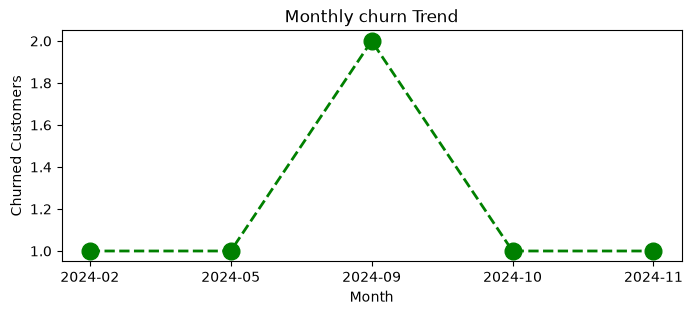

In [144]:
#4.1 Monthly Churn Trend(Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')
chrun_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(chrun_trend.index.astype('str'), chrun_trend.values, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=12)

plt.title("Monthly churn Trend")
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

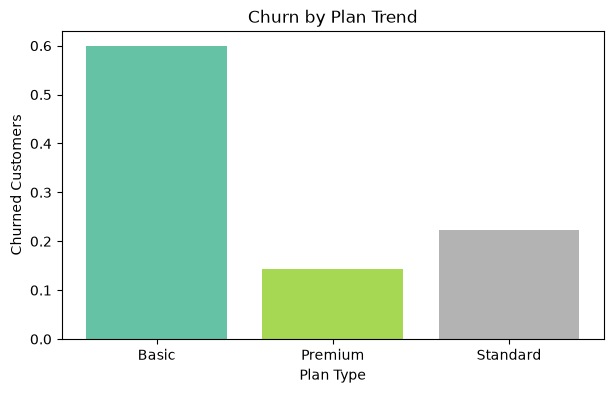

In [151]:
#4.2 Churn by Plan Type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()
# colors = ['red', 'green', 'yellow']
colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title("Churn by Plan Trend")
plt.xlabel('Plan Type')
plt.ylabel('Churned Customers')
plt.show()


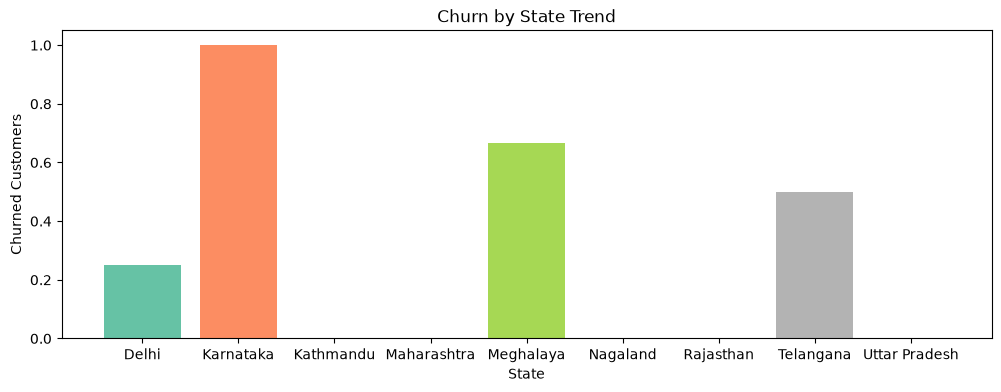

In [155]:
#4.3 Churn by States
churn_plan = df_visual.groupby('state')['churn_flag'].mean()
colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title("Churn by State Trend")
plt.xlabel('State')
plt.ylabel('Churned Customers')
plt.show()

In [ ]:
#Visualization using seaborn

In [157]:
#encoding - Convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [165]:
df_encoded = df_visual[['plan_type', 'contract_type','churn_score','churn_flag','escalations','churn_risk']].head()

catergorial_col = ['plan_type', 'contract_type', 'churn_risk']

for col in catergorial_col:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

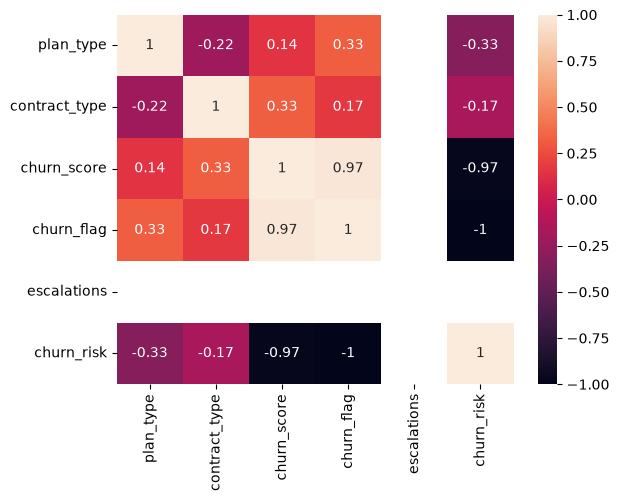

In [167]:
#Heatmap(correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

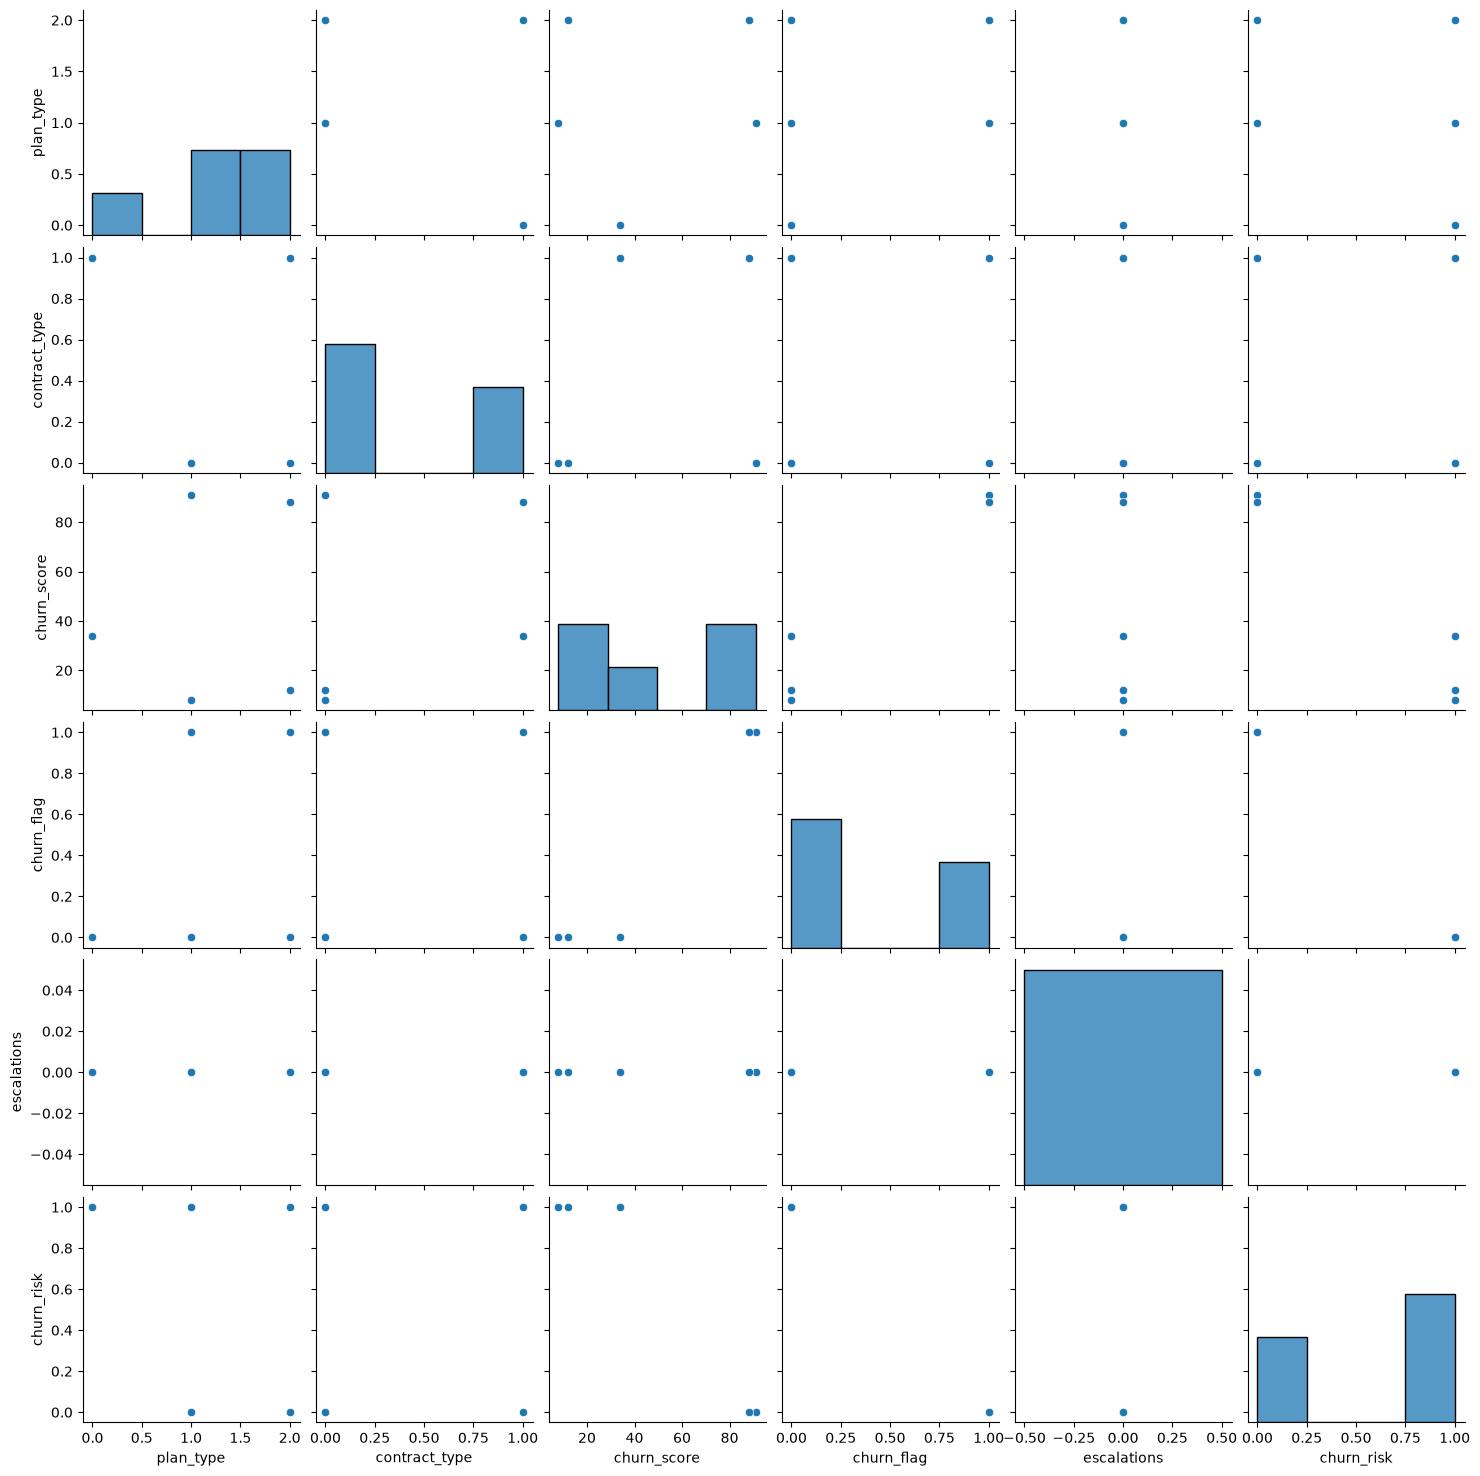

In [168]:
#pairplot - reattionship in a dataset
sns.pairplot(df_encoded)

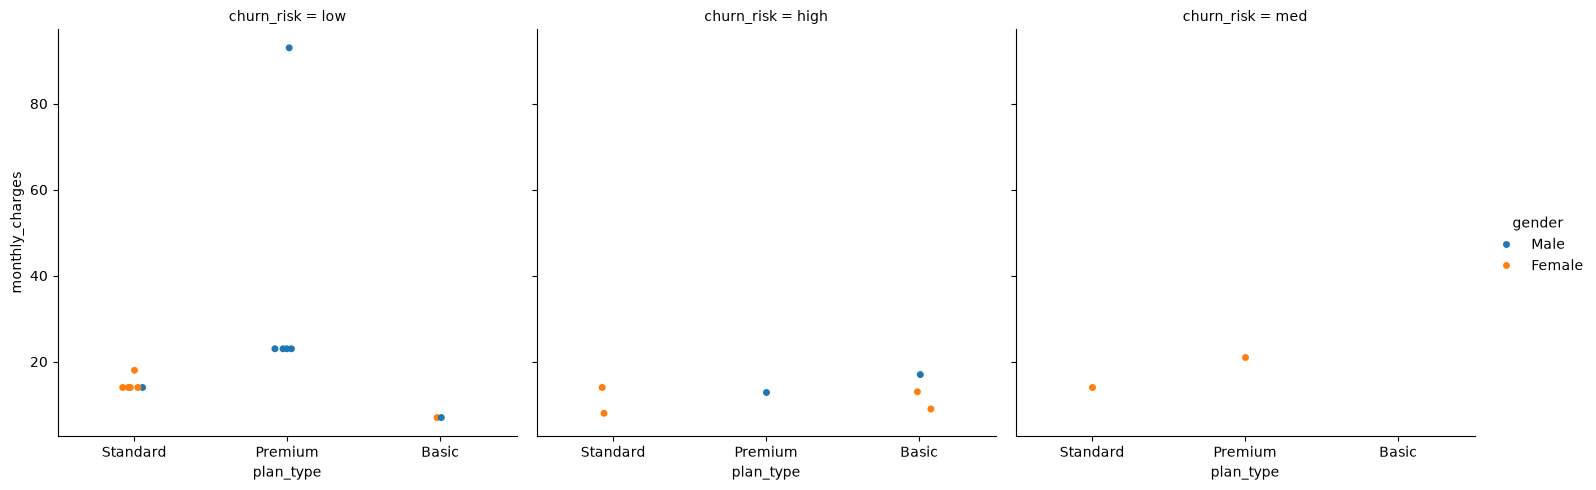

In [169]:
#catplot/Facegrid plot - Multi-dim comparison
sns.catplot(
    data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk'
)

In [ ]:
#Pivot table

In [171]:
pd.pivot_table(
    df_visual, 
    values='churn_flag',
    index='plan_type',
    aggfunc='mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [172]:
pd.pivot_table(
    df_visual, 
    values=['monthly_charges','customerid','churn_flag'],
    index='plan_type',
    aggfunc={
        'monthly_charges': 'sum',
        'customerid': 'nunique',
        'churn_flag':'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [ ]:
#Working with SQL in Python(pandas)

In [176]:
#create db in sql
conn = sqlite3.connect('test1_database.sqlite')

#table details
conn.execute("CREATE TABLE myusers1(first_name TEXT, country TEXT, budget INTEGER)")

#commit and save
conn.commit()


In [180]:
#insert data
cursor = conn.cursor()

#write sql query to insert records in sql table
cursor.execute(
    """
    INSERT INTO myusers1 VALUES
    ('Achit', 'India', 10000),
    ('Ashish', 'Germany', 25000),
    ('Vishal', 'Japan',5000)
    
    """
)

#commit and save
conn.commit()

print("Data inserted successfully")

In [183]:
#check inserted data and table
conn = sqlite3.connect('test1_database.sqlite')

query = """ SELECT * FROM myusers1"""

df_results = pd.read_sql(query, conn)

df_results.head()

,first_name,country,budget
0,Achit,India,10000
1,Ashish,Germany,25000
2,Vishal,Japan,5000


In [184]:
#aggrigation
query = """
        SELECT country, sum(budget) as total_budget FROM myusers1 GROUP BY country
"""

df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,Germany,25000
1,India,10000
2,Japan,5000


In [185]:
conn.close()